In [ ]:
# Biblioteca para operações numéricas
import numpy as np

# Para visualização
import matplotlib.pyplot as plt

# Para redes neurais
import tensorflow as tf

# Interface de alto nível para construir redes neurais
from tensorflow import keras

# Importando as camadas da rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, \
 Flatten, Dense, Dropout

# Funções utilitárias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array

# Carregar a base de Dados CIFAR-10

In [ ]:
# Carregar a base CIFAR
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar os valores para um intervalo [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# y vem como coluna.
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião", "automóvel", "pássaro", "gato", "cervo",
               "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print(f"Formato de X_train: ", X_train.shape)
print(f"Formato de y_train: ", y_train.shape)
print(f"Formato de X_test: ", X_test.shape)
print(f"Formato de y_test: ", y_test.shape)



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 33s 0us/step
Formato de X_train:  (50000, 32, 32, 3)
Formato de y_train:  (50000,)
Formato de X_test:  (10000, 32, 32, 3)
Formato de y_test:  (10000,)


# Plotar Algumas Imagens

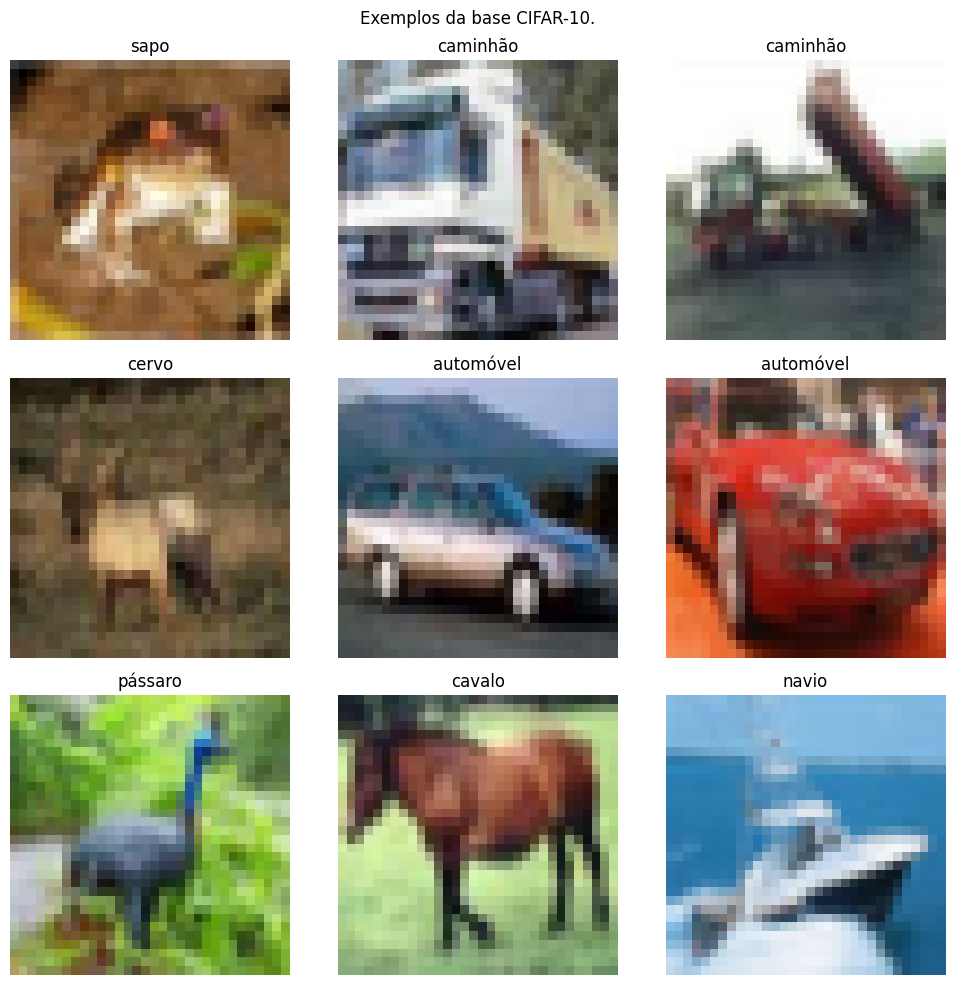

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Exemplos da base CIFAR-10.")
plt.tight_layout()
plt.show()

# Criação do Modelo CNN

In [ ]:
model = keras.Sequential()

# Camada de Entrada
model.add(Input(shape=(32, 32, 3)))

# Bloco 1
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 2
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 3
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Transição CNN => Dense (Totalmente conectada)
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compilar
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo da arquitetura do modelo
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,682 (158.91 KB)

 Trainable params: 40,682 (158.91 KB)

 Non-trainable params: 0 (0.00 B)

# Treinar a Rede

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64,
                    validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3619 - loss: 1.7422 - val_accuracy: 0.4638 - val_loss: 1.4847
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4979 - loss: 1.4007 - val_accuracy: 0.5184 - val_loss: 1.3396
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5479 - loss: 1.2689 - val_accuracy: 0.5642 - val_loss: 1.2570
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5807 - loss: 1.1826 - val_accuracy: 0.5698 - val_loss: 1.2312
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6072 - loss: 1.1150 - val_accuracy: 0.6006 - val_loss: 1.1461
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6292 - loss: 1.0569 - val_accuracy: 0.6107 - val_loss: 1.1092
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6449 - loss: 1.0105 - val_accuracy: 0.6102 - val_loss: 1.0930
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6616 - loss: 0.9683 - val_accuracy: 0.

# Plot da Acurácia e Loss

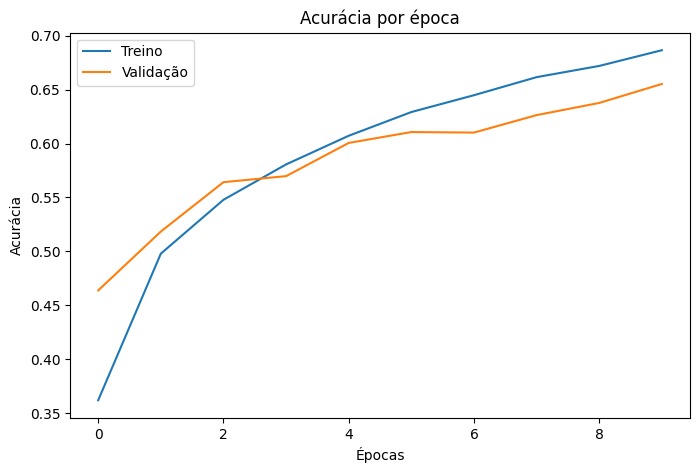

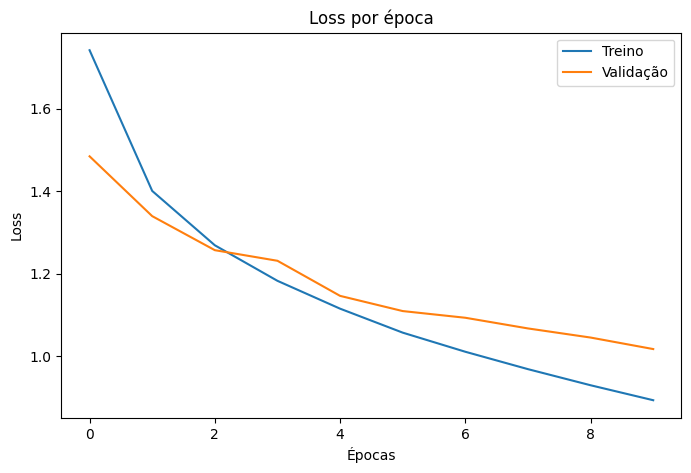

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label="Treino")
plt.plot(history.history['val_accuracy'], label="Validação")
plt.title("Acurácia por época")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label="Treino")
plt.plot(history.history['val_loss'], label="Validação")
plt.title("Loss por época")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()